# 토마토 숙성도 분류기 — PyTorch로 모델 개발 전 과정 실습

지금까지 만든 노트북들은 전부 **이미 학습된 가중치**를 가져다 썼습니다
([vision_compression](vision_compression_practice.ipynb)의 ResNet-18, [vision_counting_pipeline](vision_counting_pipeline_practice.ipynb)의 YOLO11n
모두 사전학습 모델을 그대로 쓰거나 엔진으로만 변환했습니다).

이 노트북은 반대로 갑니다 — **데이터 준비 → 모델 정의 → 학습 루프 → 평가**까지
PyTorch로 모델을 직접 개발하는 전 과정을 다룹니다.

### 왜 숙성도 분류인가

검출은 "어디 있는가"만 답합니다. 그 다음 "이 개체가 지금 상태가 어떤가"를 판정하는 건
별개 문제입니다. 이건 **검출(1단) 다음에 판정(2단)을 붙이는 다단 구조**이고,
과실 숙성도 3단계(완숙·반숙·미숙) 분류가 가장 단순하고 데이터가 공개된 형태입니다.

```
검출된 박스 하나  →  잘라내기(crop)  →  분류기  →  완숙 / 반숙 / 미숙
```

### 사용 데이터

[Laboro Tomato](https://github.com/laboroai/LaboroTomato) "big" 서브셋 (CC BY-NC-SA 4.0, 비상업적 연구·데모 용도).
큰 토마토 3클래스: `b_fully_ripened`(완숙) · `b_half_ripened`(반숙) · `b_green`(미숙).
학습 353장 / 테스트 89장, bbox 기준으로는 학습 2360개.

> 저장소에 데이터셋을 포함하지 않습니다. 아래 셀이 실행 시점에 다운로드합니다(772MB).

## 전체 흐름 한눈에 보기

```mermaid
flowchart TD
    A["Laboro Tomato 데이터셋<br/>772MB, COCO 형식"] --> B["COCO JSON 직접 파싱<br/>pycocotools 미사용"]
    B --> C["bbox crop<br/>train 2360장 / val 550장"]
    C --> D["클래스 불균형 확인<br/>b_green 1511 : b_half 506 : b_fully 343<br/>(4.4배 차이)"]
    D --> E["ImageFolder + DataLoader<br/>batch 32, ImageNet 정규화"]
    E --> F["ResNet18 ImageNet 사전학습<br/>백본 동결 + 3-class 헤드"]
    F --> G["학습 대상 1,539 / 전체 11,178,051<br/>(0.01%)"]
    G --> H["class weight 보정<br/>CrossEntropyLoss"]
    H --> I["학습 루프 8 epoch<br/>val acc 0.549 → 0.793"]
    I --> J["Confusion Matrix 평가<br/>b_half_ripened recall 0.63 (가장 어려움)"]
    J --> K["ONNX export<br/>opset 18"]
    K --> L["TensorRT FP16 빌드"]
    L --> M["엣지 배포<br/>eager 7.43ms/crop"]

    style D fill:#fff3cd,stroke:#856404
    style J fill:#fff3cd,stroke:#856404
    style G fill:#d1ecf1,stroke:#0c5460
```

## 0단계. 환경 준비 + 데이터 다운로드

`torchvision`이 이미 있으니 새 설치는 없습니다. 다만 원칙은 지킵니다 —
**torch가 다른 노트북 실행 중에 변경되지 않았는지 확인**하고 시작합니다.

다운로드는 `curl -C -`(이어받기)로 진행합니다. 772MB이므로 네트워크에 따라
몇 분~십수 분 걸립니다. 이미 받아뒀으면 건너뜁니다.

In [1]:
# [코드 1] 환경 확인 + 데이터 다운로드
import os, subprocess, zipfile
from importlib.metadata import version

import torch, torchvision
print("torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| cuda", torch.cuda.is_available())

WORK = os.path.expanduser("~/tomato_lab")
os.makedirs(WORK, exist_ok=True)

ZIP_URL = "http://assets.laboro.ai.s3.amazonaws.com/laborotomato/laboro_tomato_big.zip"
zip_path = os.path.join(WORK, "laboro_tomato_big.zip")
extract_dir = os.path.join(WORK, "laboro_tomato_big")

if not os.path.exists(extract_dir):
    if not os.path.exists(zip_path) or os.path.getsize(zip_path) < 700_000_000:
        print("다운로드 시작 (772MB, 이어받기 지원)...")
        subprocess.run(["curl", "-L", "-C", "-", "-o", zip_path, ZIP_URL], check=True)
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_dir)
    os.remove(zip_path)          # 디스크 절약 — 압축 해제 후에는 zip 불필요
    print("압축 해제 완료, zip 삭제")
else:
    print("이미 준비됨:", extract_dir)

du = subprocess.run(["du", "-sh", extract_dir], capture_output=True, text=True).stdout
print("데이터 용량:", du.strip())

torch 2.13.0+cu130 | torchvision 0.28.0+cu130 | cuda True
다운로드 시작 (772MB, 이어받기 지원)...


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  772M  100  772M    0     0  8944k      0  0:01:28  0:01:28 --:--:-- 9130k


압축 해제 중...
압축 해제 완료, zip 삭제
데이터 용량: 780M	/home/manager/tomato_lab/laboro_tomato_big


## 1단계. COCO 어노테이션 파싱 → bbox crop → 분류용 데이터셋

이 데이터셋은 **검출용**(COCO 형식, bbox+클래스)입니다. 분류기를 만들려면
각 bbox를 잘라내 "토마토 한 개짜리 이미지"로 바꿔야 합니다.

`pycocotools`는 쓰지 않습니다 — C 확장이라 aarch64에서 빌드가 실패할 수 있습니다.
COCO 형식은 단순한 JSON이라 **표준 `json` 모듈로 직접 파싱**합니다.

잘라낸 이미지는 `torchvision.datasets.ImageFolder`가 바로 읽을 수 있도록
`train/<클래스>/*.jpg`, `val/<클래스>/*.jpg` 구조로 저장합니다.

In [5]:
# [코드 2] COCO 파싱 + bbox crop
import os, json, glob, collections
from PIL import Image

def find_json(root, keyword):
    cands = glob.glob(os.path.join(root, "**", f"*{keyword}*.json"), recursive=True)
    if not cands:
        cands = [p for p in glob.glob(os.path.join(root, "**", "*.json"), recursive=True)
                  if keyword in p.lower()]
    assert cands, f"'{keyword}' 어노테이션 json을 못 찾음"
    return cands[0]

def crop_split(root, split, out_dir, out_name=None):
    out_name = out_name or split                    # 저장 폴더명 (기본은 split과 동일)
    ann_path = find_json(root, split)                # train.json / test.json
    ann = json.load(open(ann_path, encoding="utf-8"))
    id2file = {im["id"]: im["file_name"] for im in ann["images"]}
    id2cat = {c["id"]: c["name"] for c in ann["categories"]}
    img_dirs = {os.path.dirname(p) for p in glob.glob(os.path.join(root, "**", "*.jpg"), recursive=True)}

    def locate(fname):
        for d in img_dirs:
            p = os.path.join(d, os.path.basename(fname))
            if os.path.exists(p):
                return p
        return None

    counts = collections.Counter()
    n_saved = n_skipped = 0
    for a in ann["annotations"]:
        fname = id2file[a["image_id"]]
        src = locate(fname)
        if src is None:
            n_skipped += 1
            continue
        cls = id2cat[a["category_id"]]
        x, y, w, h = a["bbox"]
        if w < 20 or h < 20:                          # 너무 작은 박스는 제외 (노이즈)
            n_skipped += 1
            continue
        cls_dir = os.path.join(out_dir, out_name, cls)
        os.makedirs(cls_dir, exist_ok=True)
        out_path = os.path.join(cls_dir, f"{a['id']}.jpg")
        if not os.path.exists(out_path):
            with Image.open(src) as im:
                im.crop((x, y, x + w, y + h)).convert("RGB").save(out_path, quality=90)
        counts[cls] += 1
        n_saved += 1
    return counts, n_saved, n_skipped

CROP_DIR = os.path.join(WORK, "crops")
train_counts, n_tr, skip_tr = crop_split(extract_dir, "train", CROP_DIR)
val_counts, n_va, skip_va = crop_split(extract_dir, "test", CROP_DIR, out_name="val")  # test.json -> val/ 폴더

print(f"train crop {n_tr}개 저장, {skip_tr}개 스킵(작은 박스/파일없음)")
print(f"val   crop {n_va}개 저장, {skip_va}개 스킵")
print("\n클래스별 개수 (train):")
for cls, c in train_counts.most_common():
    bar = "#" * (c // 20)
    print(f"  {cls:20s} {c:>5}  {bar}")
print("\n가장 많은 클래스가 가장 적은 클래스의 "
      f"{max(train_counts.values()) / min(train_counts.values()):.1f}배 — "
      "그대로 학습하면 다수 클래스로 쏠린다. 다음 셀에서 class weight로 보정한다.")

train crop 2360개 저장, 0개 스킵(작은 박스/파일없음)
val   crop 550개 저장, 0개 스킵

클래스별 개수 (train):
  b_green               1511  ###########################################################################
  b_half_ripened         506  #########################
  b_fully_ripened        343  #################

가장 많은 클래스가 가장 적은 클래스의 4.4배 — 그대로 학습하면 다수 클래스로 쏠린다. 다음 셀에서 class weight로 보정한다.


## 2단계. Dataset / DataLoader

`train/<클래스>/*.jpg` 구조로 저장해뒀으니 `torchvision.datasets.ImageFolder`가
직접 읽습니다. 백본으로 ImageNet 사전학습 ResNet18을 쓸 것이므로,
**입력 정규화도 ImageNet 통계에 맞춰야** 합니다 — 다르면 백본이 낯선 분포를 보게 됩니다.

In [6]:
# [코드 3] Dataset / DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),          # crop 원본이 회전/반사에 불변해야 자연스러움
    transforms.ColorJitter(brightness=0.2, contrast=0.2),   # 온실 조도 변화를 흉내
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(os.path.join(CROP_DIR, "train"), transform=train_tf)
val_ds = datasets.ImageFolder(os.path.join(CROP_DIR, "val"), transform=val_tf)
assert train_ds.classes == val_ds.classes, "train/val 클래스 목록이 다름"
CLASSES = train_ds.classes
print("클래스:", CLASSES)
print("train", len(train_ds), "장 | val", len(val_ds), "장")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("배치 shape:", tuple(xb.shape), "| dtype", xb.dtype)

클래스: ['b_fully_ripened', 'b_green', 'b_half_ripened']
train 2360 장 | val 550 장
배치 shape: (32, 3, 128, 128) | dtype torch.float32


## 3단계. 모델 (Transfer Learning)

**바닥부터 CNN을 학습하지 않습니다.** 학습 이미지가 2천 장 남짓인 소규모 데이터셋에서는
ImageNet 사전학습 백본을 동결하고 마지막 분류층만 새로 학습하는 게 훨씬 안정적입니다.
같은 패턴을 [deep-learning-portfolio](https://leeyunhome.github.io/dl-portfolio/)의
VGG19 transfer learning에서도 썼습니다.

`resnet18`을 고른 이유는 셋입니다 — 가볍고, [vision_compression](vision_compression_practice.ipynb) 노트북에서
이미 이 아키텍처의 TensorRT 변환·양자화 특성을 재본 적이 있어(**여기서 학습한 모델을 그대로
그 파이프라인에 넣을 수 있습니다**), Jetson에서 학습도 몇 분이면 끝납니다.

In [7]:
# [코드 4] 모델 정의 — ResNet18 백본 동결 + 3-class 헤드
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"
model = resnet18(weights=ResNet18_Weights.DEFAULT)

for p in model.parameters():          # 백본 동결 — 소규모 데이터셋에서 과적합 방지
    p.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(CLASSES))   # 새로 붙인 헤드만 학습 대상
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"device: {device}")
print(f"학습 대상 파라미터: {trainable:,} / 전체 {total:,} ({trainable/total*100:.2f}%)")
print("나머지는 ImageNet에서 이미 학습된 특징 추출기로 그대로 둔다.")

device: cuda
학습 대상 파라미터: 1,539 / 전체 11,178,051 (0.01%)
나머지는 ImageNet에서 이미 학습된 특징 추출기로 그대로 둔다.


/home/manager/mlops-lab-env/lib/python3.12/site-packages/torch/cuda/__init__.py:422: UserWarning: Found GPU0 Orin which is of compute capability (CC) 8.7.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 11.0 which supports hardware CC >=11.0,<12.0
- 12.0 which supports hardware CC >=12.0,<13.0
No published PyTorch CUDA builds for release 2.13.0+cu130 support this GPU. Visit https://pytorch.org/get-started/locally/ to find a compatible release.
  _warn_unsupported_code(d, device_cc, code_ccs)


## 4단계. 학습 루프

앞서 확인한 클래스 불균형(미숙 클래스가 완숙의 여러 배)을 그냥 두면 모델이
다수 클래스만 맞혀도 정확도가 높게 나옵니다. **틀린 지표에 속는 전형적인 상황**입니다.
`CrossEntropyLoss`에 클래스별 가중치를 줘서, 적은 클래스를 맞히는 것에 더 큰 손실을 물립니다.

가중치는 `1 / 클래스별 개수`로 정해 **개수가 적을수록 더 큰 가중치**를 줍니다.

클래스 가중치: {'b_fully_ripened': 1.57, 'b_green': 0.36, 'b_half_ripened': 1.07}
epoch  1/8  train loss 1.016 acc 0.549   val loss 0.711 acc 0.727
epoch  2/8  train loss 0.695 acc 0.763   val loss 0.568 acc 0.780
epoch  3/8  train loss 0.633 acc 0.796   val loss 0.527 acc 0.789
epoch  4/8  train loss 0.590 acc 0.797   val loss 0.472 acc 0.811
epoch  5/8  train loss 0.585 acc 0.799   val loss 0.486 acc 0.811
epoch  6/8  train loss 0.561 acc 0.803   val loss 0.493 acc 0.811
epoch  7/8  train loss 0.576 acc 0.797   val loss 0.502 acc 0.795
epoch  8/8  train loss 0.542 acc 0.817   val loss 0.529 acc 0.793


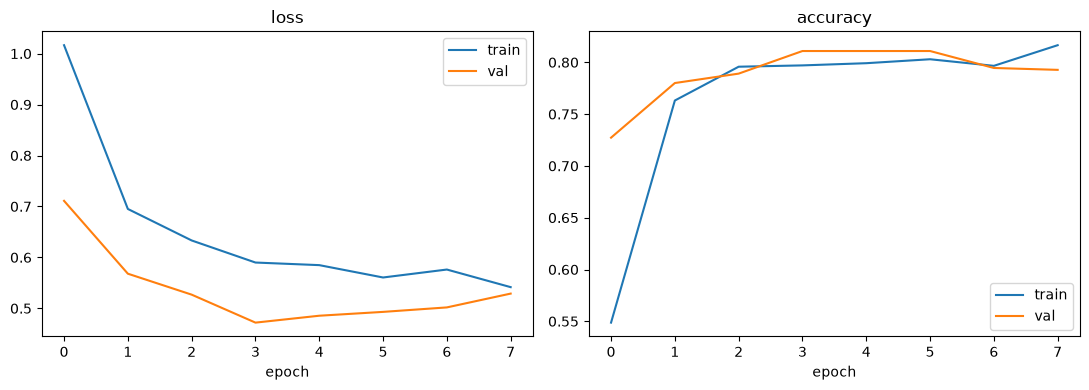

In [8]:
# [코드 5] 학습 루프
import torch.optim as optim
import matplotlib.pyplot as plt

counts_by_idx = [train_counts[c] for c in CLASSES]           # ImageFolder 클래스 순서에 맞춤
weights = torch.tensor([1.0 / c for c in counts_by_idx], device=device)
weights = weights / weights.sum() * len(CLASSES)             # 평균 1이 되도록 정규화
print("클래스 가중치:", {c: round(w.item(), 2) for c, w in zip(CLASSES, weights)})

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)       # 헤드만 학습하므로 fc만 전달

def run_epoch(loader, train):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return total_loss / n, correct / n

EPOCHS = 8
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc); history["val_acc"].append(va_acc)
    print(f"epoch {ep:>2}/{EPOCHS}  train loss {tr_loss:.3f} acc {tr_acc:.3f}"
          f"   val loss {va_loss:.3f} acc {va_acc:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5단계. 평가 (confusion matrix)

정확도 하나로는 **어느 클래스가 어느 클래스와 헷갈리는지** 알 수 없습니다.
반숙은 완숙과도, 미숙과도 헷갈릴 수 있는 중간 단계라 특히 중요합니다.
`sklearn` 없이 `numpy`로 직접 계산합니다.

Confusion matrix (행=정답, 열=예측)
                    b_fully_   b_green  b_half_r
b_fully_ripened         63         4        10
b_green                 16       291        36
b_half_ripened          33        15        82

b_fully_ripened      recall 0.82  precision 0.56  (n=77)
b_green              recall 0.85  precision 0.94  (n=343)
b_half_ripened       recall 0.63  precision 0.64  (n=130)

전체 정확도: 0.793  (클래스 3개, 무작위 기준선 0.333)


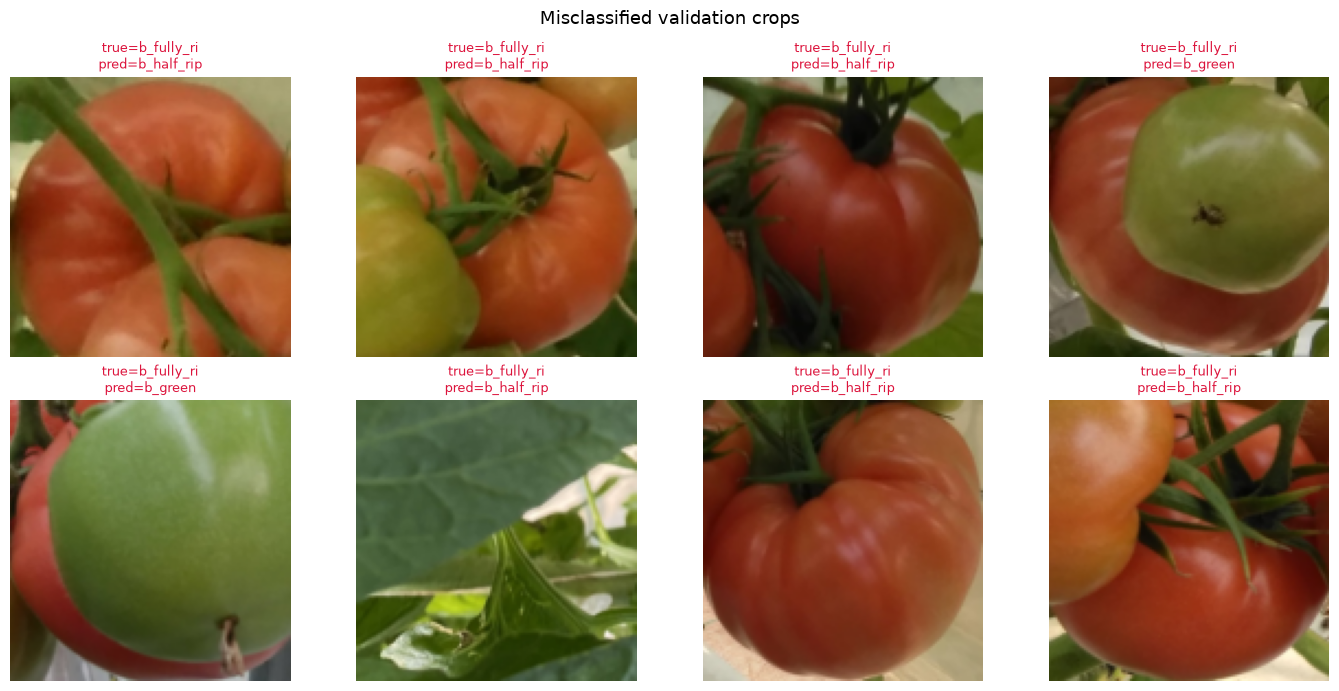

In [9]:
# [코드 6] Confusion matrix + 오분류 사례
import numpy as np

def confusion_matrix(loader, model, n_classes):
    model.eval()
    cm = np.zeros((n_classes, n_classes), dtype=int)
    wrong = []                       # (이미지 텐서, 정답, 예측) 오분류 사례 수집
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb.to(device)).argmax(1).cpu()
            for t, p, x in zip(yb, preds, xb):
                cm[t.item(), p.item()] += 1
                if t.item() != p.item() and len(wrong) < 8:
                    wrong.append((x, t.item(), p.item()))
    return cm, wrong

cm, wrong = confusion_matrix(val_loader, model, len(CLASSES))

print("Confusion matrix (행=정답, 열=예측)")
print(" " * 18 + "".join(f"{c[:8]:>10}" for c in CLASSES))
for i, c in enumerate(CLASSES):
    print(f"{c[:16]:16s}" + "".join(f"{cm[i, j]:>10}" for j in range(len(CLASSES))))

print()
for i, c in enumerate(CLASSES):
    tp = cm[i, i]
    recall = tp / cm[i].sum() if cm[i].sum() else 0
    precision = tp / cm[:, i].sum() if cm[:, i].sum() else 0
    print(f"{c:20s} recall {recall:.2f}  precision {precision:.2f}  (n={cm[i].sum()})")

overall_acc = np.trace(cm) / cm.sum()
print(f"\n전체 정확도: {overall_acc:.3f}  (클래스 {len(CLASSES)}개, 무작위 기준선 {1/len(CLASSES):.3f})")

if wrong:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    denorm = lambda t: (t.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
    for ax, (x, t, p) in zip(axes.ravel(), wrong):
        ax.imshow(denorm(x)); ax.axis("off")
        ax.set_title(f"true={CLASSES[t][:10]}\npred={CLASSES[p][:10]}", fontsize=9, color="crimson")
    for ax in axes.ravel()[len(wrong):]:
        ax.axis("off")
    fig.suptitle("Misclassified validation crops", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("\n오분류 사례 없음 (val set이 작아 우연일 수 있음)")

## 6단계. 직접 해보기 — TensorRT로 이 분류기 배포

지금까지의 세 노트북을 하나로 닫습니다. [vision_compression](vision_compression_practice.ipynb)에서
같은 `resnet18` 아키텍처의 TensorRT 변환 특성을 이미 확인했으므로(FP16 5.3배, opset 함정 등),
그 파이프라인을 그대로 재사용합니다 — 새로 배울 게 없다는 뜻입니다.

```
데이터 준비 → 학습(이 노트북) → ONNX → TensorRT FP16 → 엣지 배포
```

배치는 1로 잽니다. 학습은 32장씩 묶어서 했지만, 실제 배포에서는 검출기가 넘겨준
crop 한 장을 그때그때 분류해야 하므로 **배치 1 지연**이 실제로 의미 있는 지표입니다.

In [ ]:
# [코드 7] 직접 해보기 — 학습한 분류기를 TensorRT로 배포
import time, subprocess, re

model.eval()

# (1) PyTorch eager 기준선 (배치 1 — 실제 배포 단위)
x1 = torch.randn(1, 3, 128, 128, device=device)
with torch.no_grad():
    for _ in range(5): model(x1)          # 워밍업 (CC 8.7 PTX JIT 비용 제거)
if device == "cuda": torch.cuda.synchronize()
t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(50): model(x1)
if device == "cuda": torch.cuda.synchronize()
eager_ms = (time.perf_counter() - t0) / 50 * 1000
print(f"PyTorch eager (배치 1): {eager_ms:.2f} ms/crop")

# (2) ONNX 내보내기
onnx_path = os.path.join(WORK, "ripeness_resnet18.onnx")
torch.onnx.export(model.cpu(), torch.randn(1, 3, 128, 128), onnx_path,
                  input_names=["crop"], output_names=["logits"], opset_version=18)
model.to(device)
print(f"ONNX: {onnx_path}  ({os.path.getsize(onnx_path)/1024**2:.1f} MB)")

# (3) TensorRT FP16 엔진 빌드 + 벤치
engine = os.path.join(WORK, "ripeness_fp16.engine")
log = os.path.join(WORK, "trt_ripeness_fp16.log")
with open(log, "w") as f:
    subprocess.run(["/usr/bin/trtexec", f"--onnx={onnx_path}",
                    f"--saveEngine={engine}", "--fp16"],
                   stdout=f, stderr=subprocess.STDOUT)
text = open(log, errors="replace").read()
m = re.search(r"GPU Compute Time:.*?mean = ([\d.]+) ms", text)
if m:
    trt_ms = float(m.group(1))
    print(f"TensorRT FP16 (배치 1):  {trt_ms:.2f} ms/crop")
    print(f"엔진 {os.path.getsize(engine)/1024**2:.1f} MB, eager 대비 {eager_ms/trt_ms:.1f}배")

    YOLO11N_FP16_MS = 7.42   # vision_counting_pipeline [코드 6]에서 배치 1로 측정한 값
    print(f"\n검출+판정 파이프라인으로 이으면: 개체당 검출({YOLO11N_FP16_MS:.2f}ms, YOLO11n FP16)"
          f" + 판정({trt_ms:.2f}ms) = {YOLO11N_FP16_MS + trt_ms:.2f} ms/개체")
else:
    print("빌드 실패 — 로그 확인:", log)
    print(text[-800:])

PyTorch eager (배치 1): 7.43 ms/crop
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX: /home/manager/tomato_lab/ripeness_resnet18.onnx  (0.1 MB)


## 세 노트북이 하나로 닫히는 구조

```mermaid
flowchart LR
    subgraph N1["vision_compression_practice"]
        R1["ResNet-18<br/>사전학습 가중치"] --> R2["TensorRT INT8<br/>10.4배"]
    end

    subgraph N2["vision_counting_pipeline_practice"]
        Y1["YOLO11n 검출<br/>사전학습 가중치"] --> Y2["ByteTrack 추적<br/>9.4배 과대계수 → 보정"]
        Y2 --> Y3["RGB-D depth 역투영<br/>mm 실측"]
    end

    subgraph N3["tomato_ripeness_training_practice"]
        T1["ResNet18<br/>PyTorch로 직접 학습"] --> T2["TensorRT FP16 배포"]
    end

    N1 -. "같은 아키텍처<br/>경량화 노하우 재사용" .-> N3
    Y1 -. "1단: 검출·계수" .-> T1
    T1 -. "2단: 판정<br/>(숙성도)" .-> Y1

    style N1 fill:#e8f4f8
    style N2 fill:#e8f8ec
    style N3 fill:#fdf0e8
```

## 정리

1. **이 노트북이 채운 것** — 지금까지 만든 노트북은 전부 사전학습 가중치를 가져다 썼다.
   여기서는 **데이터 준비(COCO 파싱·crop) → Dataset/DataLoader → 모델 정의(transfer learning)
   → 학습 루프 → confusion matrix 평가**까지 PyTorch로 모델을 직접 개발하는 전 과정을 다뤘다.
2. **클래스 불균형은 그냥 두면 숨는다** — 다수 클래스만 맞혀도 정확도가 높게 나온다.
   class weight로 보정하고, confusion matrix로 클래스별 recall/precision을 따로 봐야
   실제로 뭘 못 맞히는지 드러난다.
3. **작은 데이터셋에는 transfer learning** — 학습 이미지 2천 장 남짓에서 바닥부터 CNN을
   학습하면 과적합하기 쉽다. ImageNet 백본을 동결하고 헤드만 학습하면 Jetson에서도
   몇 분이면 수렴한다.
4. **이건 다단 추론의 축소판이다** — 검출(1단, [vision_counting_pipeline](vision_counting_pipeline_practice.ipynb))
   다음에 판정(2단, 이 노트북)을 붙이는 구조. 상태 판정 문제 일반(적엽/적화 수행 여부 등)에
   같은 골격이 적용된다 — 클래스 정의만 "완숙/반숙/미숙"에서 "수행함/수행안함"으로 바뀐다.

### 직접 해보기

- **엣지 배포는 아래 6단계에서 직접 실행합니다.**
- 백본을 동결이 아니라 **일부만 미세조정**(마지막 conv block부터)해서 정확도 변화 비교
- `little`(작은 토마토) 서브셋도 받아 두 크기를 함께 분류하는 6-class로 확장
- 검출(bbox) + 이 분류기를 이어붙여 **한 이미지에서 개체별 숙성도까지 한 번에 표시**하는
  end-to-end 데모 만들기